<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AI_BASED_FINANCIAL_MARKET_PREDICTION_PROJECT_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

Financial markets are highly dynamic and influenced by a wide range of factors, including historical stock prices, trading volume, market trends, analyst opinions, and public sentiment expressed through financial news. Traditional stock price prediction methods often struggle to capture the complex and nonlinear relationships among these factors, leading to less accurate forecasts.

The objective of this project is to develop an AI-based Financial Market Prediction system that predicts the next day's stock closing price using historical market data and news sentiment information. The project leverages machine learning and deep learning techniques to analyze key financial indicators such as open price, previous close price, trading volume, volatility, RSI, MACD, market trends, analyst ratings, and news sentiment. By identifying patterns and relationships within these variables, the system aims to generate accurate stock price predictions that can support investors, traders, and financial institutions in making informed investment decisions.

The challenge lies in effectively integrating numerical financial data with qualitative sentiment-based information while handling real-world data issues such as missing values, duplicates, and market fluctuations. Therefore, this project focuses on building and evaluating predictive models capable of improving forecasting accuracy and enhancing decision-making in financial markets.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression

In [ ]:
df=pd.read_csv("/content/Financial_Market_Prediction_Modified.csv")
df

,Date,Stock_Symbol,Sector,Market_Trend,News_Sentiment,Analyst_Rating,Open_Price,Previous_Close,Volume,Volatility,RSI,MACD,Next_Day_Close_Price
0,2021-01-01 00:00:00,GOOGL,Technology,Bullish,Positive,Hold,413.63,396.29,2248059,2.96,31.90,0.546,334.87
1,2021-01-01 01:00:00,TSLA,Automotive,Bullish,Negative,Buy,313.24,314.73,1420254,1.83,72.95,-2.636,277.44
2,2021-01-01 02:00:00,GOOGL,Technology,Bullish,Neutral,Hold,100.82,89.48,4251154,6.18,34.91,3.075,117.93
3,2021-01-01 03:00:00,MSFT,Technology,Bearish,Positive,Buy,377.25,360.56,758929,2.31,38.63,2.254,312.48
4,2021-01-01 04:00:00,AMZN,Consumer,Bullish,Positive,Buy,192.96,189.07,4031249,5.07,30.13,-2.653,181.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2026-09-15 03:00:00,AMZN,Consumer,Neutral,Negative,Hold,126.49,119.51,738412,7.49,53.36,-0.396,131.44
49996,2026-09-15 04:00:00,MSFT,Technology,Bullish,Neutral,Buy,124.80,97.36,3719490,7.91,26.98,-0.838,136.96
49997,2026-09-15 05:00:00,GOOGL,Technology,Bearish,Neutral,Buy,351.30,357.52,1320227,3.46,71.19,-1.084,338.41
49998,2026-09-15 06:00:00,AMZN,Consumer,Bullish,Positive,Buy,368.55,367.11,542748,7.49,39.19,0.865,317.19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  50000 non-null  object 
 1   Stock_Symbol          50000 non-null  object 
 2   Sector                50000 non-null  object 
 3   Market_Trend          50000 non-null  object 
 4   News_Sentiment        50000 non-null  object 
 5   Analyst_Rating        50000 non-null  object 
 6   Open_Price            50000 non-null  float64
 7   Previous_Close        50000 non-null  float64
 8   Volume                50000 non-null  int64  
 9   Volatility            50000 non-null  float64
 10  RSI                   50000 non-null  float64
 11  MACD                  50000 non-null  float64
 12  Next_Day_Close_Price  50000 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 5.0+ MB


In [ ]:
df.isnull().sum()

,0
Date,0
Stock_Symbol,0
Sector,0
Market_Trend,0
News_Sentiment,0
Analyst_Rating,0
Open_Price,0
Previous_Close,0
Volume,0
Volatility,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(50000, 13)

In [ ]:
df.columns

Index(['Date', 'Stock_Symbol', 'Sector', 'Market_Trend', 'News_Sentiment',
       'Analyst_Rating', 'Open_Price', 'Previous_Close', 'Volume',
       'Volatility', 'RSI', 'MACD', 'Next_Day_Close_Price'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  50000 non-null  object 
 1   Stock_Symbol          50000 non-null  object 
 2   Sector                50000 non-null  object 
 3   Market_Trend          50000 non-null  object 
 4   News_Sentiment        50000 non-null  object 
 5   Analyst_Rating        50000 non-null  object 
 6   Open_Price            50000 non-null  float64
 7   Previous_Close        50000 non-null  float64
 8   Volume                50000 non-null  int64  
 9   Volatility            50000 non-null  float64
 10  RSI                   50000 non-null  float64
 11  MACD                  50000 non-null  float64
 12  Next_Day_Close_Price  50000 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 5.0+ MB


In [ ]:
target='Next_Day_Close_Price'

In [ ]:
df[target].value_counts()

,count
Next_Day_Close_Price,
204.14,9
332.65,9
144.42,9
293.56,9
171.06,9
...,...
267.57,1
158.74,1
99.35,1


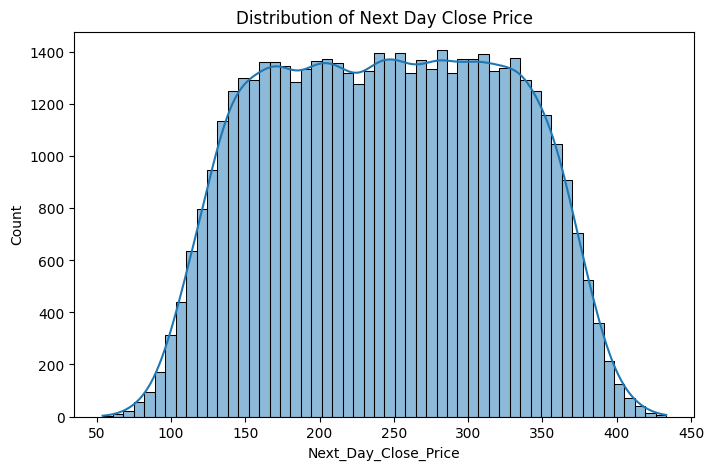

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Next_Day_Close_Price'],kde=True)
plt.title('Distribution of Next Day Close Price')
plt.show()

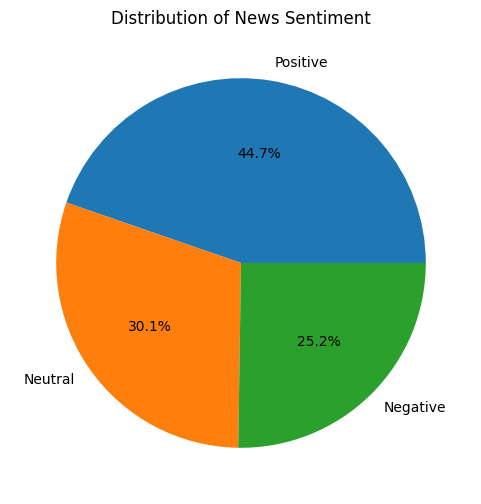

In [ ]:

df['News_Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Distribution of News Sentiment')
plt.ylabel('')
plt.show()

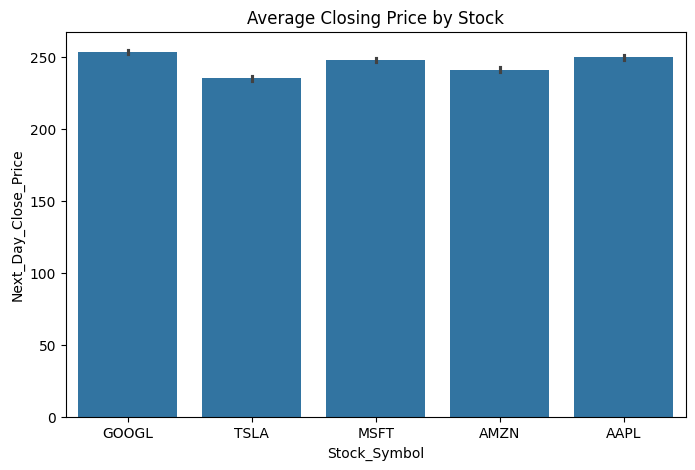

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Stock_Symbol',
            y='Next_Day_Close_Price',
            data=df)
plt.title('Average Closing Price by Stock')
plt.show()

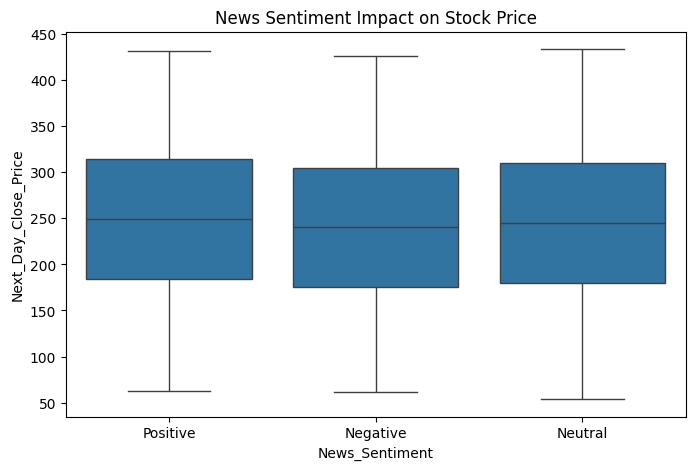

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='News_Sentiment',
            y='Next_Day_Close_Price',
            data=df)
plt.title('News Sentiment Impact on Stock Price')
plt.show()

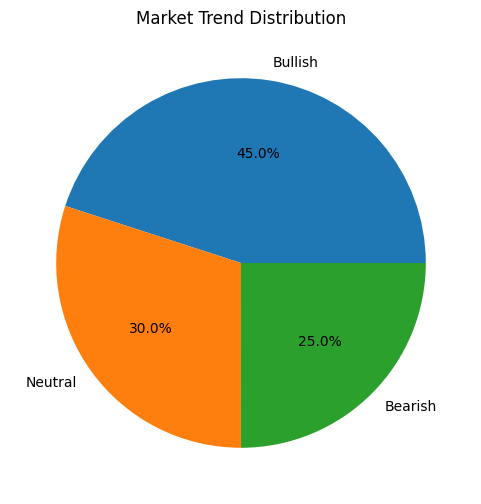

In [ ]:
df['Market_Trend'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Market Trend Distribution')
plt.ylabel('')
plt.show()

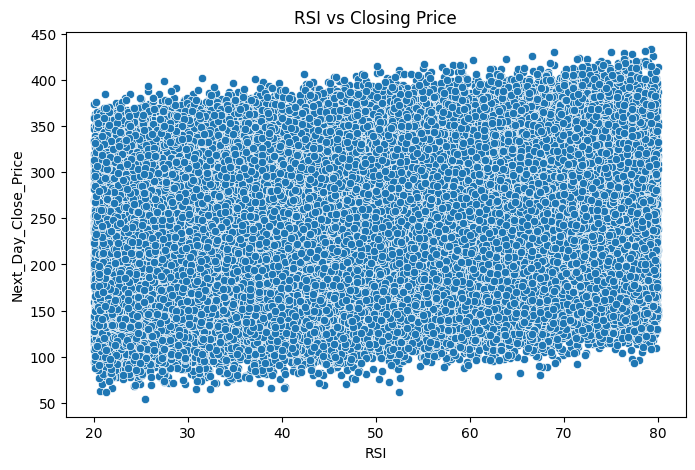

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='RSI',
                y='Next_Day_Close_Price',
                data=df)
plt.title('RSI vs Closing Price')
plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Open_Price', 'Previous_Close', 'Volume', 'Volatility', 'RSI', 'MACD',
       'Next_Day_Close_Price'],
      dtype='object')

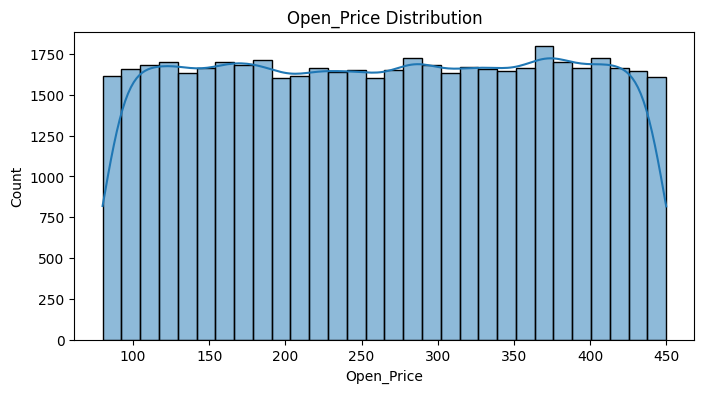

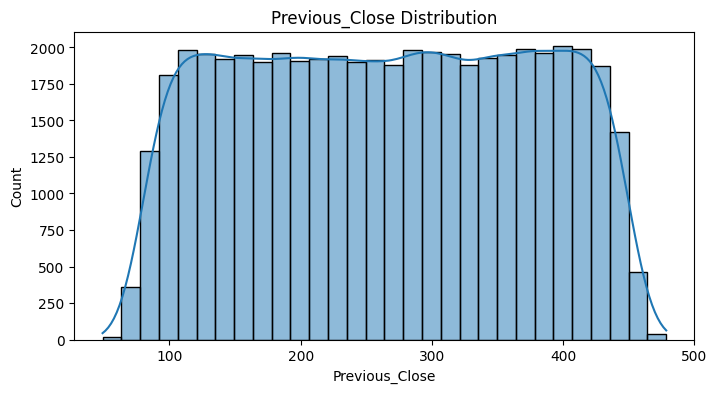

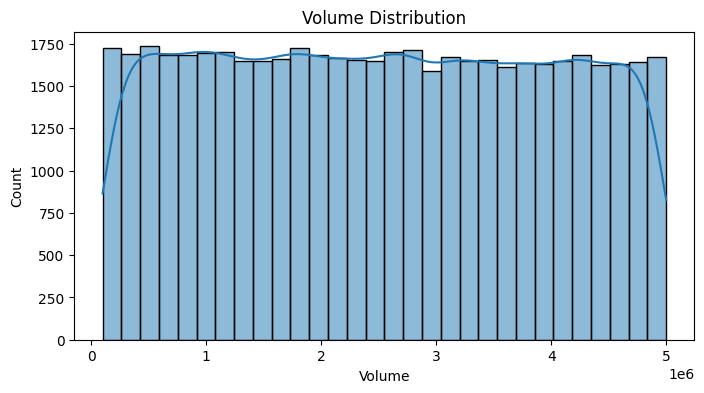

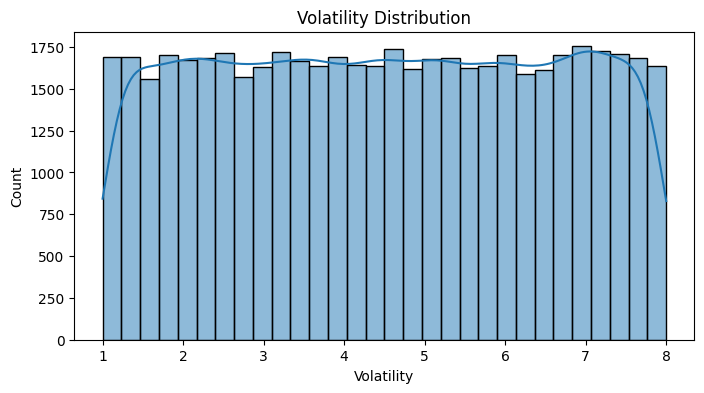

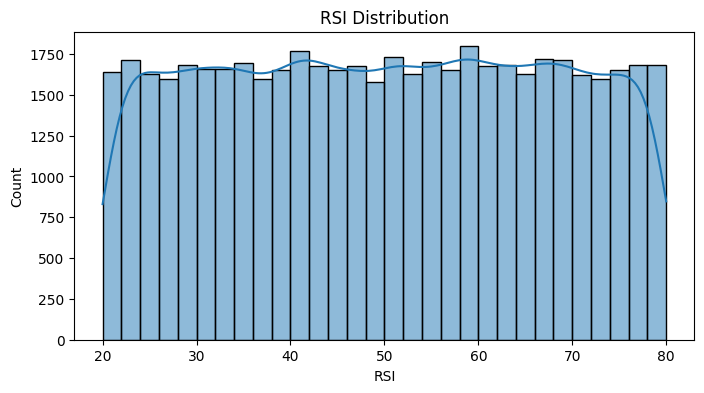

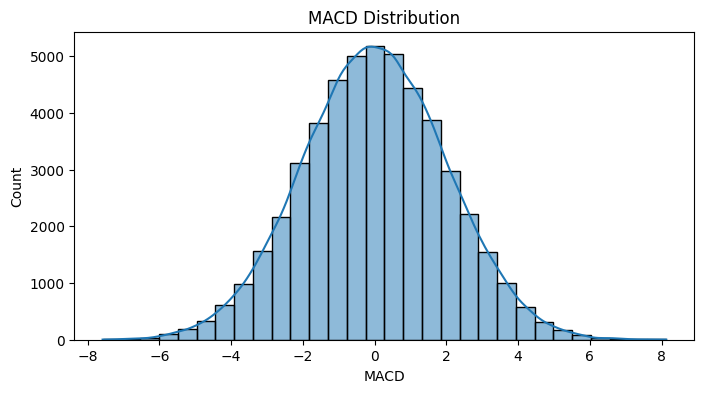

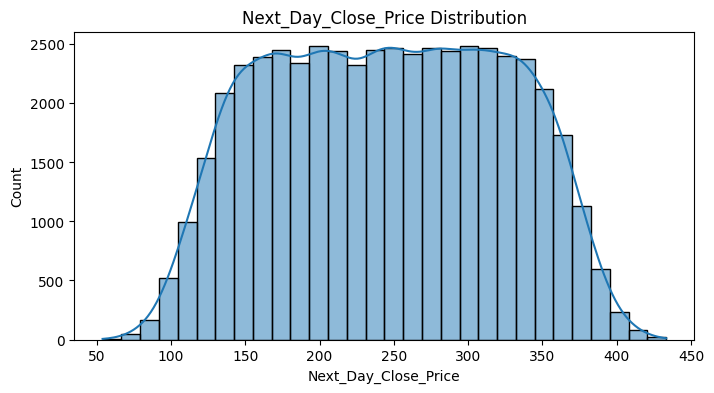

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['Date', 'Stock_Symbol', 'Sector', 'Market_Trend', 'News_Sentiment',
       'Analyst_Rating'],
      dtype='object')

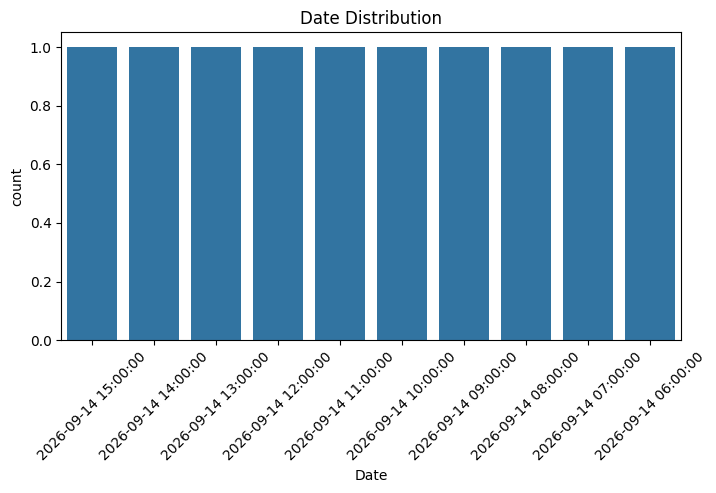

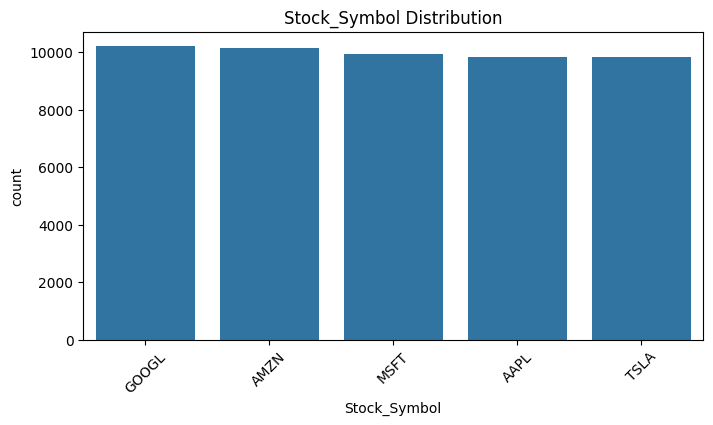

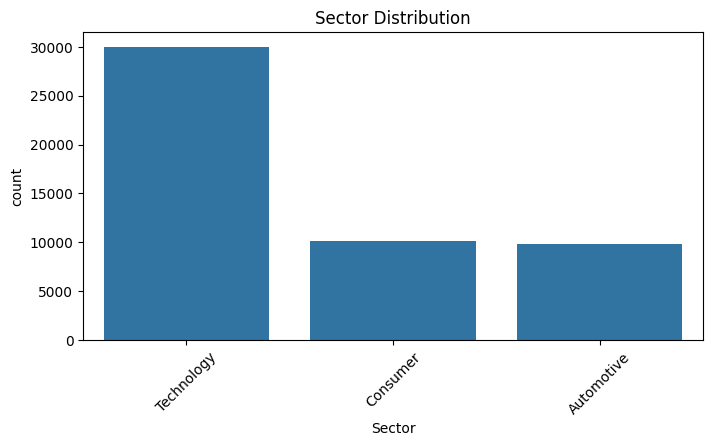

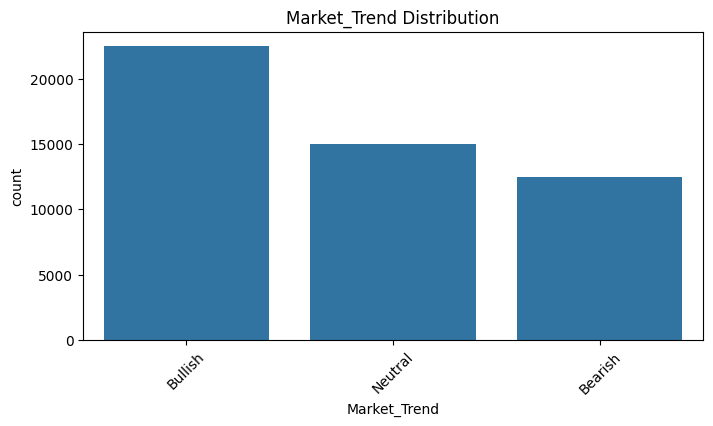

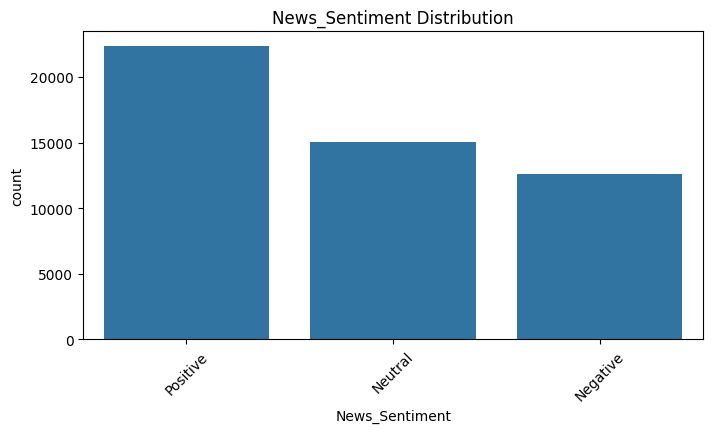

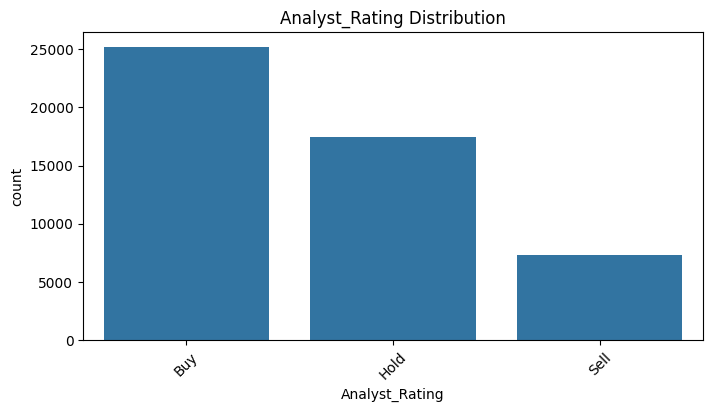

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  50000 non-null  object 
 1   Stock_Symbol          50000 non-null  object 
 2   Sector                50000 non-null  object 
 3   Market_Trend          50000 non-null  object 
 4   News_Sentiment        50000 non-null  object 
 5   Analyst_Rating        50000 non-null  object 
 6   Open_Price            50000 non-null  float64
 7   Previous_Close        50000 non-null  float64
 8   Volume                50000 non-null  int64  
 9   Volatility            50000 non-null  float64
 10  RSI                   50000 non-null  float64
 11  MACD                  50000 non-null  float64
 12  Next_Day_Close_Price  50000 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 5.0+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Stock_Symbol"]=le.fit_transform(df["Stock_Symbol"])
df["Sector"]=le.fit_transform(df["Sector"])

In [ ]:
print(df["Market_Trend"].unique())

['Bullish' 'Bearish' 'Neutral']


In [ ]:
print(df["News_Sentiment"].unique())

['Positive' 'Negative' 'Neutral']


In [ ]:
print(df["Analyst_Rating"].unique())

['Hold' 'Buy' 'Sell']


In [ ]:
df['Analyst_Rating'] = df['Analyst_Rating'].replace({
    'Hold':0, 'Buy':1, 'Sell':2
})

/tmp/ipykernel_1498/3309359725.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Analyst_Rating'] = df['Analyst_Rating'].replace({


In [ ]:
df['Market_Trend'] = df['Market_Trend'].replace({
   'Neutral':0, 'Bearish':1, 'Bullish':2
})

/tmp/ipykernel_1498/455075615.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Market_Trend'] = df['Market_Trend'].replace({


In [ ]:
df['News_Sentiment'] = df['News_Sentiment'].replace({
   'Positive':0, 'Negative':1, 'Neutral':2
})

/tmp/ipykernel_1498/2589794868.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['News_Sentiment'] = df['News_Sentiment'].replace({


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.drop('Date', axis=1, inplace=True)

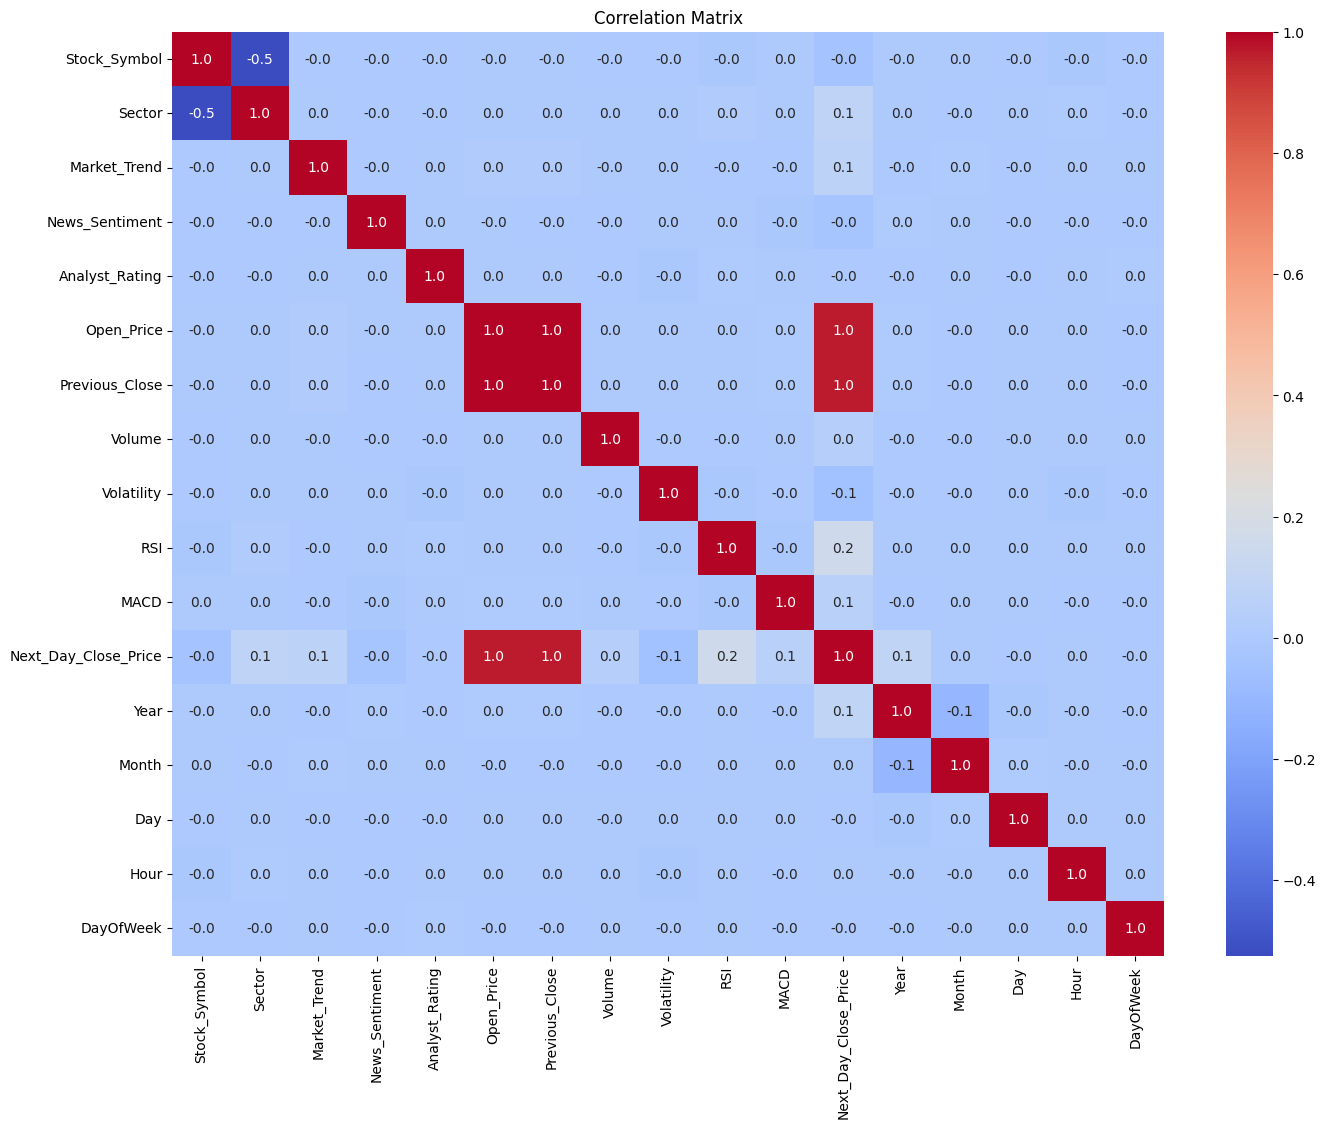

In [ ]:
core_matrix=df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop("Open_Price",axis=1,inplace=True)

In [ ]:
corr = df.corr(numeric_only=True)['Next_Day_Close_Price']
print(corr.sort_values(ascending=False))

Next_Day_Close_Price    1.000000
Previous_Close          0.964793
RSI                     0.159045
Year                    0.083628
Sector                  0.080228
Market_Trend            0.070588
MACD                    0.051859
Volume                  0.039344
Hour                    0.002010
Month                   0.000315
Day                    -0.000452
Analyst_Rating         -0.001862
DayOfWeek              -0.003634
News_Sentiment         -0.032202
Stock_Symbol           -0.039831
Volatility             -0.052250
Name: Next_Day_Close_Price, dtype: float64


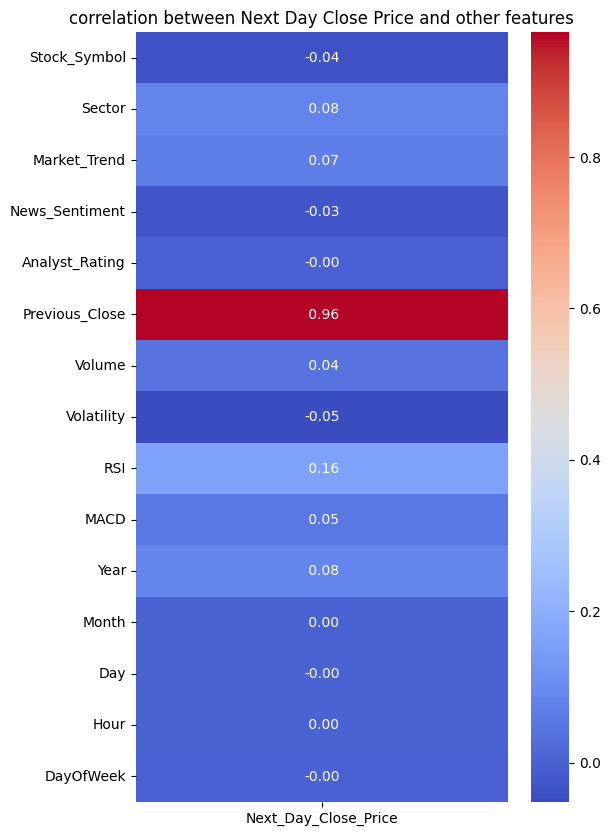

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["Next_Day_Close_Price"]
status_corr=status_corr.drop("Next_Day_Close_Price")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between Next Day Close Price and other features')
plt.show()

In [ ]:
df.columns

Index(['Stock_Symbol', 'Sector', 'Market_Trend', 'News_Sentiment',
       'Analyst_Rating', 'Previous_Close', 'Volume', 'Volatility', 'RSI',
       'MACD', 'Next_Day_Close_Price', 'Year', 'Month', 'Day', 'Hour',
       'DayOfWeek'],
      dtype='object')

In [ ]:
df.drop(['Hour','Volume', 'Volatility','Sector'],axis=1,inplace=True)

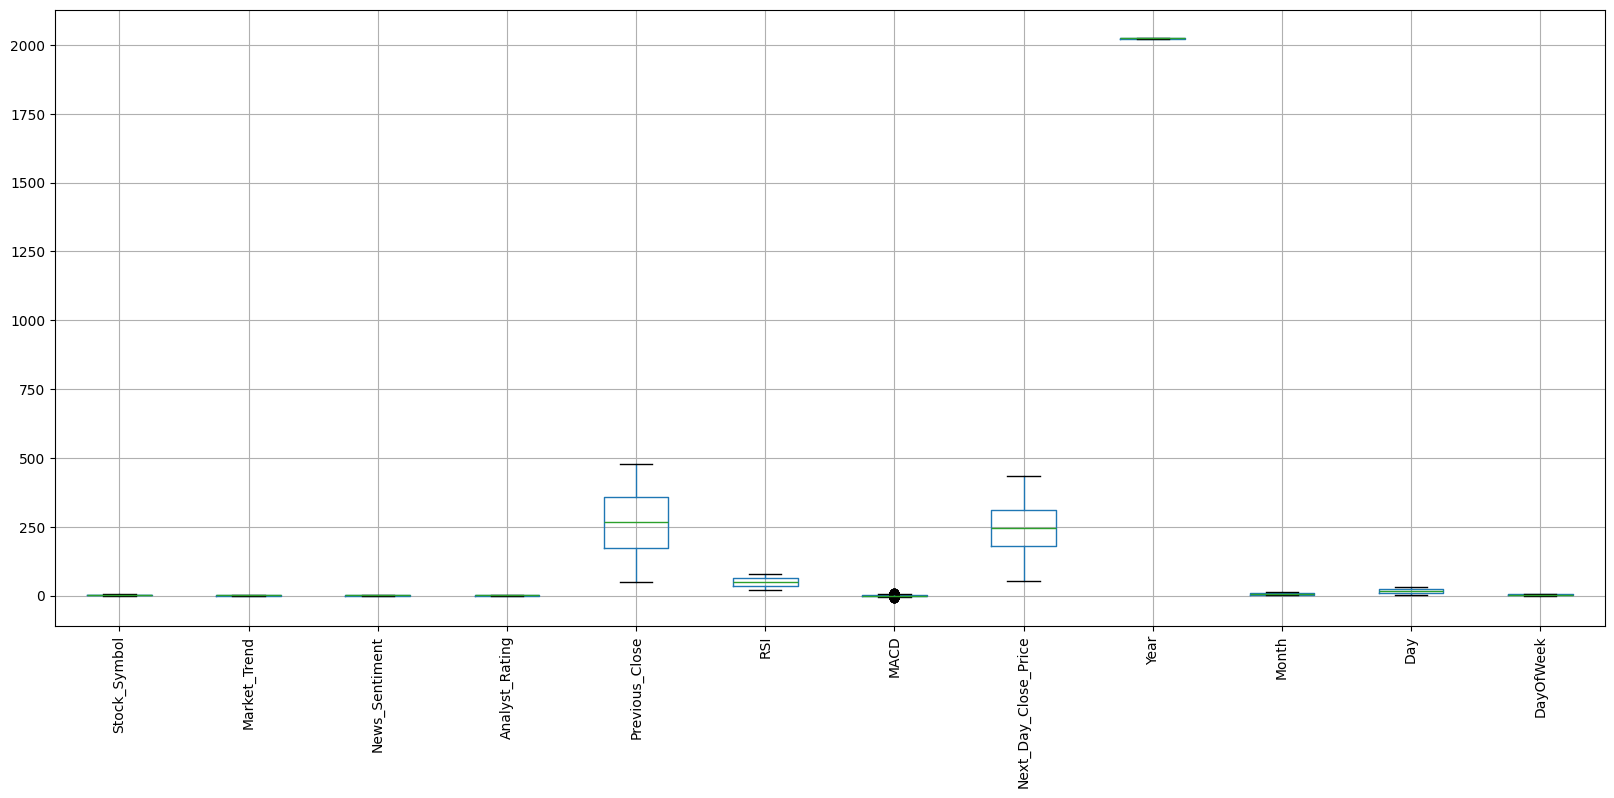

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(49655, 12)

In [ ]:
df.columns

Index(['Stock_Symbol', 'Market_Trend', 'News_Sentiment', 'Analyst_Rating',
       'Previous_Close', 'RSI', 'MACD', 'Next_Day_Close_Price', 'Year',
       'Month', 'Day', 'DayOfWeek'],
      dtype='object')

In [ ]:
features=['Stock_Symbol', 'Market_Trend', 'News_Sentiment', 'Analyst_Rating',
       'Previous_Close', 'RSI', 'MACD','Year',
       'Month', 'Day', 'DayOfWeek']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
x=df[['Stock_Symbol', 'Market_Trend', 'News_Sentiment', 'Analyst_Rating',
       'Previous_Close', 'RSI', 'MACD','Year',
       'Month', 'Day', 'DayOfWeek']]
y=df['Next_Day_Close_Price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.97


# Machine Learning

In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.95


In [ ]:
# SVR

from sklearn.svm import SVR
model=SVR(kernel="poly",degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.96


In [ ]:
#Random forest

from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.97


In [ ]:
#GradientBooster
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create model
gb_model = GradientBoostingRegressor(random_state=42)

# Train model
gb_model.fit(x_train, y_train)

# Predict
y_pred_gb = gb_model.predict(x_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R² Score: 0.9800795122417317
MAE: 8.690170031371053
RMSE: 10.923777676637412


In [ ]:
# ADABOOST

from sklearn.ensemble import AdaBoostRegressor

model=AdaBoostRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.96


In [ ]:
#xgboost

from  xgboost import XGBRegressor
model=XGBRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.98


# KFold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df.drop('Next_Day_Close_Price', axis=1)
y = df['Next_Day_Close_Price']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

best_r2 = -np.inf
best_fold = -1

best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    print(f"\nFold {fold}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R² Score:", r2)
    print("RMSE:", rmse)

    if r2 > best_r2:

        best_r2 = r2
        best_fold = fold

        best_X_train = X_train
        best_y_train = y_train

        best_X_test = X_test
        best_y_test = y_test

        best_y_pred = y_pred

print(f"\nBest Fold: {best_fold} with R² Score: {best_r2}")


Fold 1
R² Score: 0.9681883144841286
RMSE: 13.788760750179119

Fold 2
R² Score: 0.9694308724182095
RMSE: 13.625859646114828

Fold 3
R² Score: 0.9694975714920763
RMSE: 13.55055486754004

Fold 4
R² Score: 0.9697236232900808
RMSE: 13.470499355251773

Fold 5
R² Score: 0.9701377756824662
RMSE: 13.442684391387523

Best Fold: 5 with R² Score: 0.9701377756824662


In [ ]:
model=LinearRegression()
model.fit(best_X_train,best_y_train)
print("Linear Regression:",model.score(best_X_test,best_y_test))

Linear Regression: 0.9701377756824662


In [ ]:
model=RandomForestRegressor()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.9754485918848691


In [ ]:
model=DecisionTreeRegressor()
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.9466725161323192


In [ ]:
model=SVR()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.9322527593830714


In [ ]:
model=GradientBoostingRegressor(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.9809720301804102


In [ ]:
model=AdaBoostRegressor()
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.9620032998070487


In [ ]:
model=XGBRegressor()
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.9810526908140852


In [ ]:
df.shape

(49655, 12)

#Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Scale the data for deep learning
scaler_dl = MinMaxScaler()
x_train_scaled_dl = scaler_dl.fit_transform(best_X_train)
x_test_scaled_dl = scaler_dl.transform(best_X_test)

# Model
model = Sequential()
model.add(Dense(110, input_shape=(x_train_scaled_dl.shape[1],), activation='relu'))  # Hidden Layer 1
model.add(Dense(44, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1))

# Compile with regression metrics
model.compile(optimizer=Adam(learning_rate=0.001), # Adjusted learning rate for better convergence
              loss='mean_squared_error')

# Train
model.fit(x_train_scaled_dl, best_y_train, epochs=50, batch_size=32, verbose=0) # Increased epochs and added batch_size

# Predict
y_pred = model.predict(x_test_scaled_dl)

# Calculate MSE and MAE
mse = mean_squared_error(best_y_test, y_pred)
mae = mean_absolute_error(best_y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Squared Error: 102.80384851448379
Mean Absolute Error: 8.063287369556482


# Conclusion

This project developed an AI-based Financial Market Prediction system to forecast stock closing prices using historical market data and news sentiment. Several machine learning and deep learning models were evaluated, with XGBoost achieving the highest performance (R² = 98.11%), followed by Gradient Boosting (98.10%), Random Forest (97.54%), and Linear Regression (97.01%). The results show that factors such as stock prices, technical indicators, market trends, analyst ratings, trading volume, and news sentiment significantly impact stock price movements. Overall, the project demonstrates the effectiveness of AI techniques in predicting financial market trends and supporting data-driven investment decisions.


# Future scope

Future improvements can include integrating real-time stock market data, financial news, and social media sentiment to enhance prediction accuracy. Advanced models such as LSTM, GRU, and Transformers can be used to capture complex market patterns. The system can also be deployed as a web or mobile application with an interactive dashboard for real-time stock price forecasting and investment decision support.

